In [2]:
import os
import ast
import json
import pickle
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELS     = CONFIGS['experiments']
SPLIT      = 'test'

FIELDVARS    = MODELS['sr']['runs']['sr_gauss']['fieldvars']
NNSEEDS      = MODELS['nn']['seeds']
OPTIMIZEDEQS = MODELS['sr']['optimizedeqs']
PODRUNS      = MODELS['pod']['runs']
NNRUNS       = MODELS['nn']['runs']
ORDER        = ['pod_bl','nn_bl','nn_full','nn_nonparam','nn_gauss','sr_lo','sr_bl','sr_med','sr_hi']
NBINS        = 20
MINSAMPLES   = 50

COLORS = {}
LABELS = {}
for name,config in {**PODRUNS,**NNRUNS,**OPTIMIZEDEQS}.items():
    COLORS[name] = config['color']
    LABELS[name] = config['description']

SRFUNCTIONS = {
    'cube':lambda x:x**3,
    'square':lambda x:x**2,
    'neg':lambda x:-x,
    'sqrt':np.sqrt,
    'exp':np.exp,
    'log':np.log,
    'abs':np.abs,
    'max':np.maximum,
    'min':np.minimum}

In [4]:
def kernel_integrate(fields,weights,dsig,mask=None):
    w = fields*weights[None,:,:]*dsig[None,None,:]
    if mask is not None:
        w = w*mask[:,None,:]
    return w.sum(axis=2)

def physical_prediction(output):
    return np.expm1(tpstd*np.maximum(0.0,np.asarray(output,dtype=float)))

EXTRAVARS   = {}
EXTRAUNITS  = {}
EXTRALABELS = {}

def physical_predictor(p):
    '''Single accessor for any predictor: VARS entries are destandardized on the fly,
    EXTRAVARS entries (raw/derived surface quantities) are returned as-is.'''
    if p in EXTRAVARS:
        return EXTRAVARS[p][valid],EXTRALABELS[p],EXTRAUNITS[p]
    return VARS[p][valid]*STATS[f'{p}_std']+STATS[f'{p}_mean'],PHYSLABELS[p],PHYSUNITS[p]

def eval_form(form,variables,constants):
    ns = dict(SRFUNCTIONS)
    ns.update(variables)
    ns.update(constants)
    return np.asarray(eval(form,{'__builtins__':{}},ns),dtype=float)

def used_predictors(form,candidates):
    names = {n.id for n in ast.walk(ast.parse(form,mode='eval')) if isinstance(n,ast.Name)}
    return [c for c in candidates if c in names]

def models_for(*ps):
    return [name for name in MODELPREDICTORS
            if name in MODELPRED and all(p in MODELPREDICTORS[name] for p in ps)]

def bin_1d(x,z,nbins=NBINS,minsamples=MINSAMPLES,plo=1,phi=99):
    finite = np.isfinite(x)&np.isfinite(z)
    x,z    = x[finite],z[finite]
    lo,hi  = np.percentile(x,[plo,phi])
    edges  = np.linspace(lo,hi,nbins+1)
    xidxs  = np.clip(np.digitize(x,edges)-1,0,nbins-1)
    means  = np.full(nbins,np.nan)
    counts = np.zeros(nbins,dtype=int)
    for i in range(nbins):
        xidx      = xidxs==i
        counts[i] = xidx.sum()
        if counts[i]>=minsamples:
            means[i] = z[xidx].mean()
    return 0.5*(edges[:-1]+edges[1:]),means,counts

def bin_2d(x,y,z,nbins=NBINS,minsamples=MINSAMPLES,plo=1,phi=99):
    finite  = np.isfinite(x)&np.isfinite(y)&np.isfinite(z)
    x,y,z   = x[finite],y[finite],z[finite]
    xlo,xhi = np.percentile(x,[plo,phi])
    ylo,yhi = np.percentile(y,[plo,phi])
    xedges  = np.linspace(xlo,xhi,nbins+1)
    yedges  = np.linspace(ylo,yhi,nbins+1)
    xidxs   = np.clip(np.digitize(x,xedges)-1,0,nbins-1)
    yidxs   = np.clip(np.digitize(y,yedges)-1,0,nbins-1)
    flatidx = xidxs*nbins+yidxs
    sums    = np.bincount(flatidx,weights=z,minlength=nbins*nbins).reshape(nbins,nbins)
    counts  = np.bincount(flatidx,minlength=nbins*nbins).reshape(nbins,nbins)
    means   = np.where(counts>=minsamples,sums/np.maximum(counts,1),np.nan)
    return 0.5*(xedges[:-1]+xedges[1:]),0.5*(yedges[:-1]+yedges[1:]),means,counts

In [5]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
tpmean = float(STATS['tp_mean'])
tpstd  = float(STATS['tp_std'])
zmin   = (0.0-tpmean)/tpstd

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime,nlat,nlon = ds.sizes['time'],ds.sizes['lat'],ds.sizes['lon']
    nsig            = ds.sizes.get('sig',1)
    dsig            = ds['dsig'].values
    farrs      = [ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig) for v in FIELDVARS]
    fieldstack = np.stack(farrs,axis=1)
    surfmask   = (ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig)
                  if 'surfmask' in ds else None)
    def getflat(da):
        if 'time' in da.dims:
            return da.transpose('time','lat','lon').values.ravel()
        return np.tile(da.values,(ntime,1,1)).ravel()
    blnorm  = getflat(ds['bl'])
    lfnorm  = getflat(ds['lf'])
    shfnorm = getflat(ds['shf'])
    lhfnorm = getflat(ds['lhf'])

kwlist = []
for seed in NNSEEDS:
    wpath = os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc')
    if os.path.exists(wpath):
        with xr.open_dataset(wpath,engine='h5netcdf') as wds:
            kwlist.append(wds['k'].values)

ki = np.mean([kernel_integrate(fieldstack,kw,dsig,surfmask) for kw in kwlist],axis=0) if kwlist else fieldstack.mean(axis=2)
rhk,thetaek,thetaestark = ki[:,0],ki[:,1],ki[:,2]

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    obsflat = ds.tp.transpose('time','lat','lon').values.ravel()

with open(os.path.join(MODELSDIR,'sr','optimized_equations.pkl'),'rb') as f:
    SR_REGISTRY = pickle.load(f)

In [6]:
VARS = {'bl':blnorm,'rh':rhk,'thetae':thetaek,'thetaestar':thetaestark,'lf':lfnorm,'shf':shfnorm,'lhf':lhfnorm}

MODELPRED = {}
MODELPREDICTORS = {}
for name,cfg in OPTIMIZEDEQS.items():
    entry          = SR_REGISTRY.get(name,{})
    form           = entry.get('form',cfg['form'])
    constants      = entry.get('constants',cfg['init'])
    predictornames = used_predictors(form,VARS.keys())
    variables      = {p:VARS[p] for p in predictornames}
    formvals       = eval_form(form,variables,constants)
    MODELPRED[name]       = physical_prediction(formvals)
    MODELPREDICTORS[name] = predictornames

In [7]:
def load_predictions(name,predsdir,split=SPLIT):
    filepath = os.path.join(predsdir,f'{name}_{split}_predictions.nc')
    if not os.path.exists(filepath):
        return None
    with xr.open_dataset(filepath,engine='h5netcdf') as ds:
        da = ds['tp'].load()
    if 'seed' in da.dims:
        da = da.mean('seed')
    pred = da.transpose('time','lat','lon').values.ravel()
    return pred if pred.shape[0]==obsflat.shape[0] else None

for name,cfg in PODRUNS.items():
    pred = load_predictions(name,PREDSDIR)
    if pred is None:
        continue
    MODELPRED[name]       = pred
    MODELPREDICTORS[name] = [cfg['inputvar']]

for name,cfg in NNRUNS.items():
    pred = load_predictions(name,PREDSDIR)
    if pred is None:
        continue
    MODELPRED[name]       = pred
    MODELPREDICTORS[name] = cfg['fieldvars']+cfg.get('localvars',[])

print(f'Loaded predictions for: {sorted(MODELPRED.keys())}')

Loaded predictions for: ['nn_gauss_rot', 'sr_bl', 'sr_hi', 'sr_lo', 'sr_med']


In [8]:
PHYSUNITS  = {'bl':'m/s$^2$','rh':'%','thetae':'K','thetaestar':'K','lf':'0-1','shf':'W/m$^2$','lhf':'W/m$^2$'}
PHYSLABELS = {'bl':'BL','rh':'RH','thetae':r'$\theta_e$','thetaestar':r'$\theta_e^*$','lf':'LF','shf':'SHF','lhf':'LHF'}

PREDICTORS = [p for p in ['bl','rh','thetae','thetaestar','lf','shf','lhf','sef','bow','sdo'] if models_for(p)]

valid = np.isfinite(obsflat)
for arr in VARS.values():
    valid &= np.isfinite(arr)

print(f'Valid samples: {valid.sum():,}')
print(PREDICTORS)

Valid samples: 1,437,408
['bl', 'rh', 'thetae', 'thetaestar', 'lf', 'shf', 'lhf', 'sef', 'bow', 'sdo']


In [9]:
def plot_1d(predictors,density=True):
    ncols  = min(5,len(predictors))
    nrows  = -(-len(predictors)//ncols)
    fig,axs = pplt.subplots(nrows=nrows,ncols=ncols,refwidth=1.5,sharex=False,sharey=True)
    pinfo  = [physical_predictor(p) for p in predictors]
    binned = [bin_1d(x,obsflat[valid]) for x,_,_ in pinfo]
    maxcounts = max(c.max() for _,_,c in binned) if density else 0
    for i,(ax,p,(x,label,unit),(xc,obsbin,counts)) in enumerate(zip(axs,predictors,pinfo,binned)):
        if density:
            dax = ax.twinx()
            dax.bar(xc,counts,width=xc[1]-xc[0],absolute_width=True,edgecolor='none',color='gray5',alpha=0.3,zorder=0)
            lastinrow = (i+1)%ncols==0 or i==len(predictors)-1
            dax.format(ylabel='Sample Count' if lastinrow else '',ylim=(0,1.5*maxcounts))
        ax.plot(xc,obsbin,color='k',linewidth=2,label='Observed',zorder=5)
        for name in ORDER:
            if name not in models_for(p):
                continue
            _,predbin,_ = bin_1d(x,MODELPRED[name][valid])
            ax.plot(xc,predbin,color=COLORS[name],linewidth=1.5,label=LABELS[name],zorder=5)
        ax.format(grid=False,xlabel=f'{label} ({unit})')
    for ax in axs[len(predictors):]:
        ax.set_visible(False)
    axs[:,0].format(ylabel='Precipitation (mm)')
    handles = [Line2D([],[],color='k',linewidth=2,label='Observed')]
    handles += [Line2D([],[],color=COLORS[name],linewidth=1.5,label=LABELS[name]) for name in ORDER if name in MODELPRED]
    fig.legend(handles,loc='b',ncols=4)
    pplt.show()

def plot_2d(px,py,mode='value',density=True):
    x,xl,xu = physical_predictor(px)
    y,yl,yu = physical_predictor(py)
    models  = [name for name in ORDER if name in models_for(px,py)]
    xc,yc,obsbin2d,obscounts = bin_2d(x,y,obsflat[valid])
    panels  = models if mode=='diff' else ['obs']+models
    fig,axs = pplt.subplots(nrows=1,ncols=len(panels),refwidth=1.5,share=True)
    axs = np.atleast_1d(axs)
    m = None
    for ax,name in zip(axs,panels):
        if name=='obs':
            zbin2d,counts = obsbin2d,obscounts
            cmap,vmin,vmax,extend,clabel = 'Blues',0,3,'max','Precipitation (mm)'
        else:
            _,_,predbin2d,counts = bin_2d(x,y,MODELPRED[name][valid])
            if mode=='diff':
                zbin2d = predbin2d-obsbin2d
                cmap,vmin,vmax,extend,clabel = 'DryWet',-2,2,'both','Model $-$ Observed\nPrecipitation (mm)'
            else:
                zbin2d = predbin2d
                cmap,vmin,vmax,extend,clabel = 'Blues',0,3,'max','Precipitation (mm)'
        m = ax.pcolormesh(xc,yc,zbin2d.T,cmap=cmap,vmin=vmin,vmax=vmax,levels=21,extend=extend)
        if density:
            ax.contour(xc,yc,counts.T,color='red3',linewidth=0.5)
        title = 'Observed' if name=='obs' else LABELS[name]
        ax.format(title=title,xlabel=f'{xl} ({xu})',grid=False)
    axs[0].format(ylabel=f'{yl} ({yu})')
    fig.colorbar(m,loc='r',label=clabel)
    pplt.show()

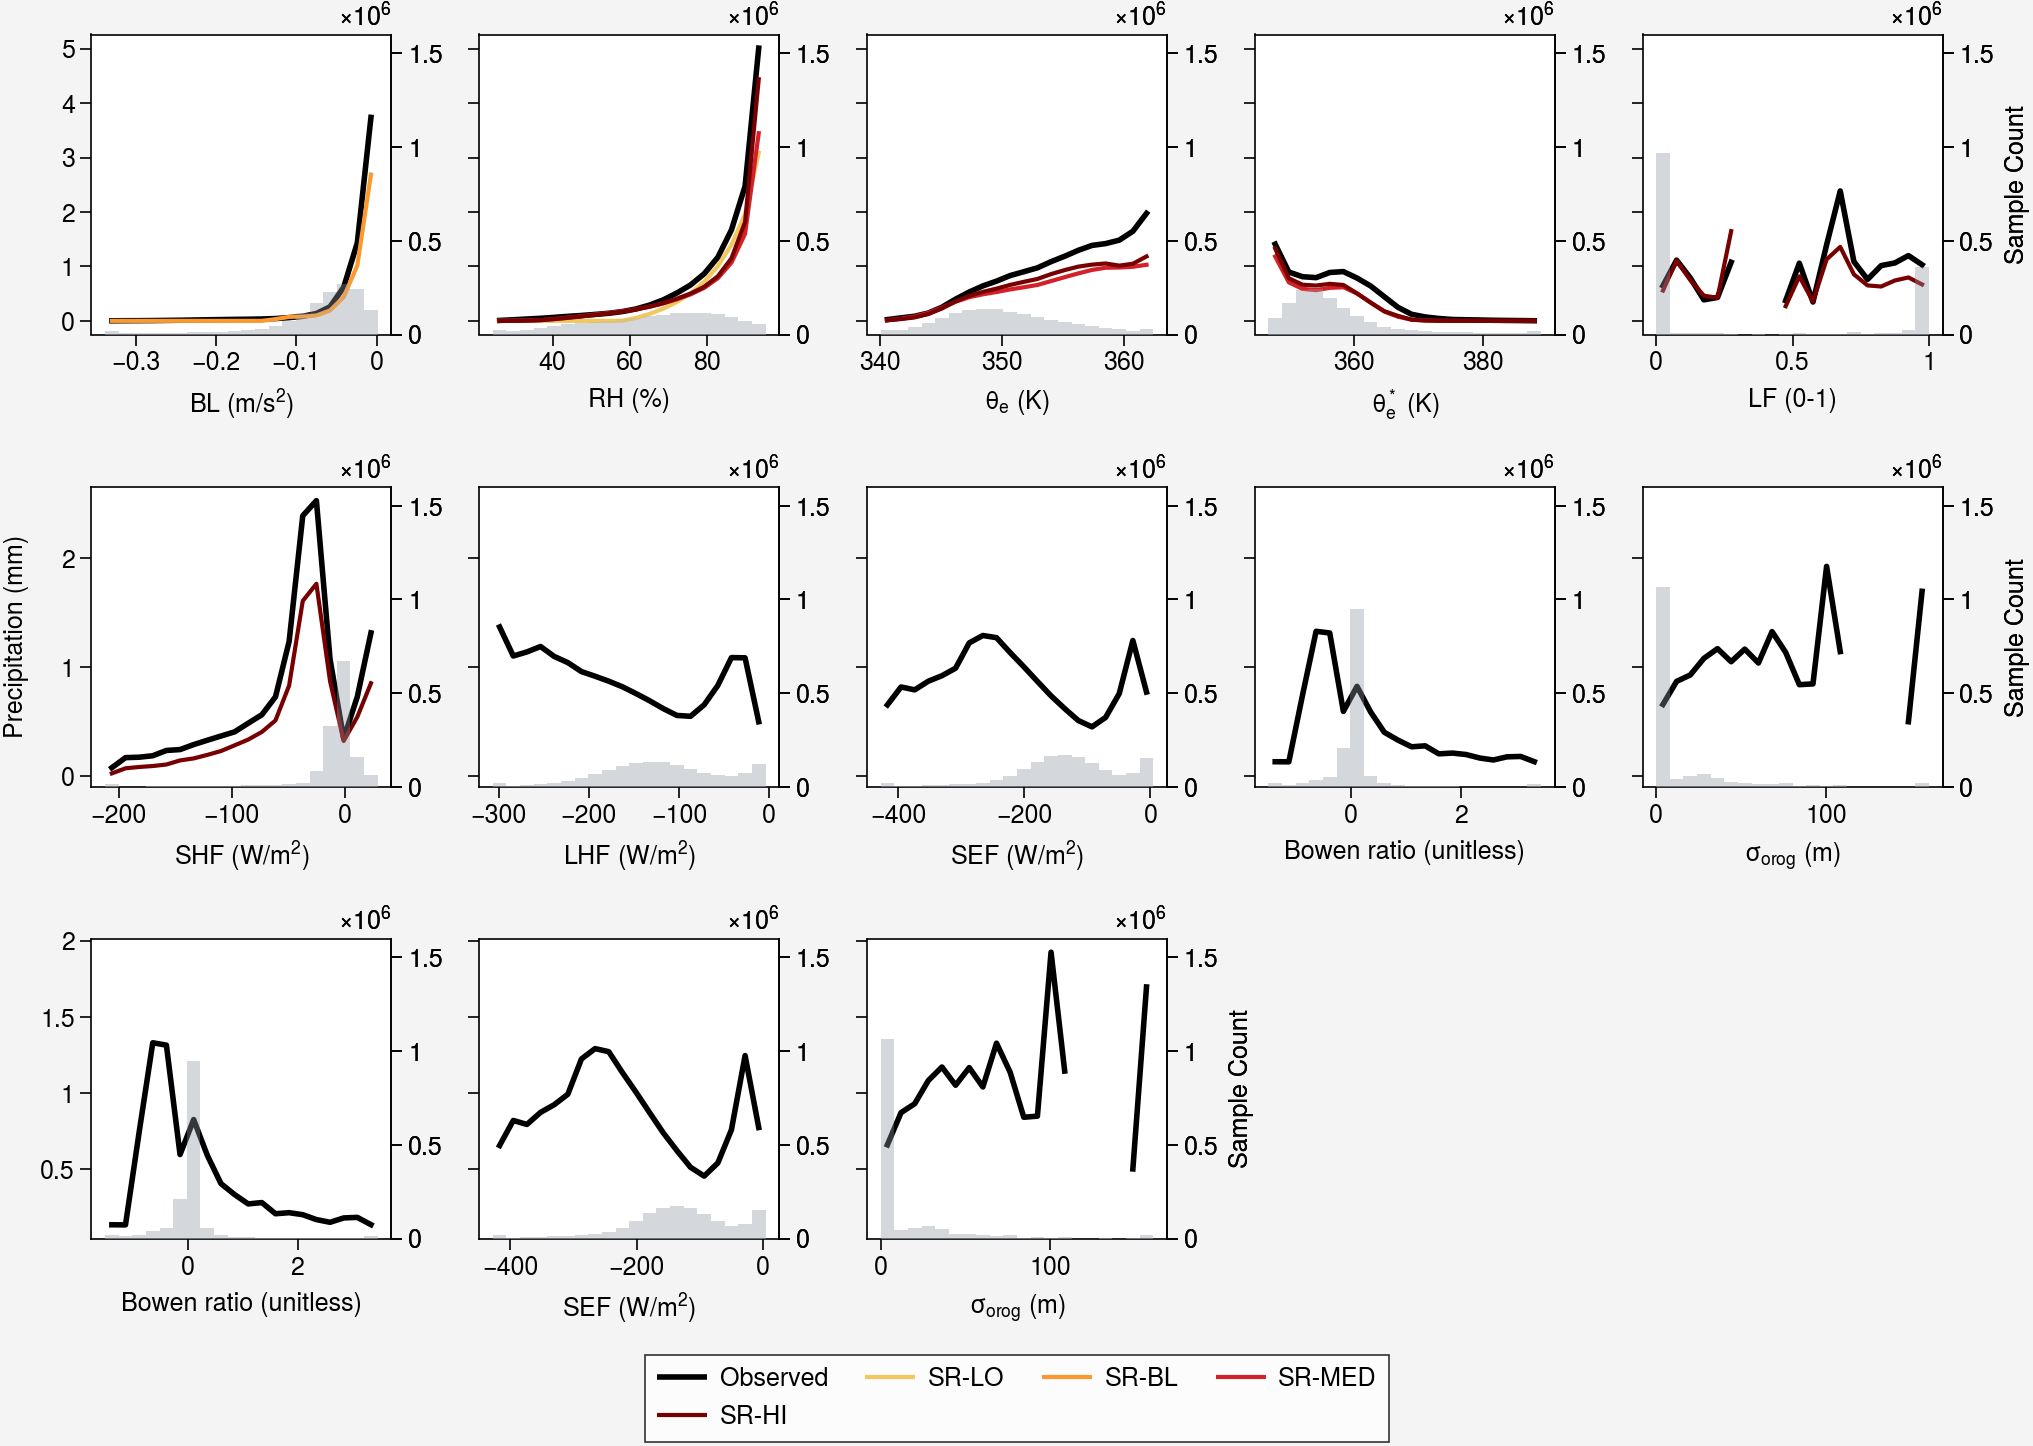

In [10]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    lfraw  = getflat(ds['lf'])
    shfraw = getflat(ds['shf'])
    lhfraw = getflat(ds['lhf'])
    sefraw = getflat(ds['sef'])
    bowraw = getflat(ds['bow'])
    sdoraw = getflat(ds['sdo'])

EXTRAVARS.update({'lf':lfraw,'shf':shfraw,'lhf':lhfraw,'sef':sefraw,'bow':bowraw,'sdo':sdoraw,})
EXTRAUNITS.update({'lf':'0-1','shf':'W/m$^2$','lhf':'W/m$^2$','sef':'W/m$^2$','bow':'unitless','sdo':'m'})
EXTRALABELS.update({'lf':'LF','shf':'SHF','lhf':'LHF','sef':'SEF','bow':'Bowen ratio','sdo':'$\sigma_{orog}$'})

plot_1d(PREDICTORS+['bow','sef','sdo'])

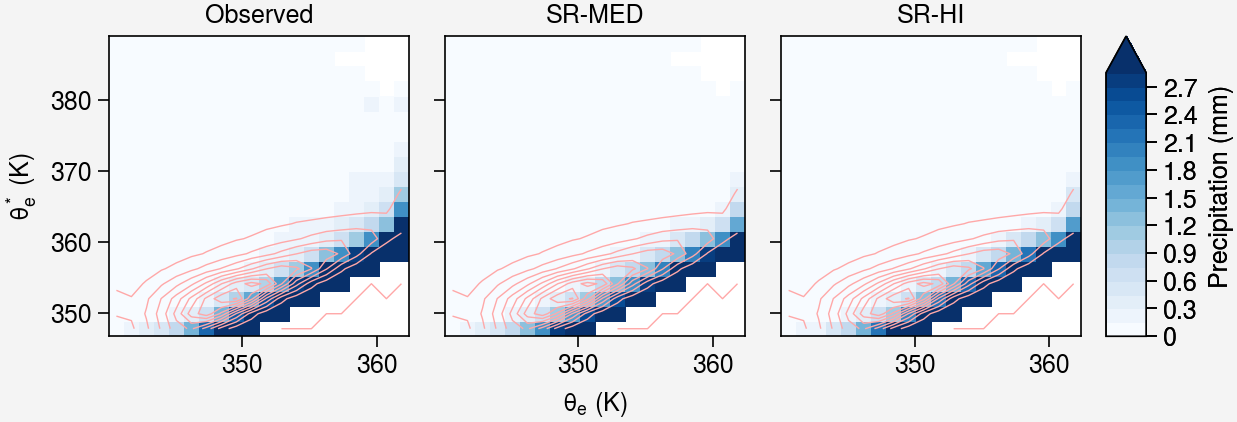

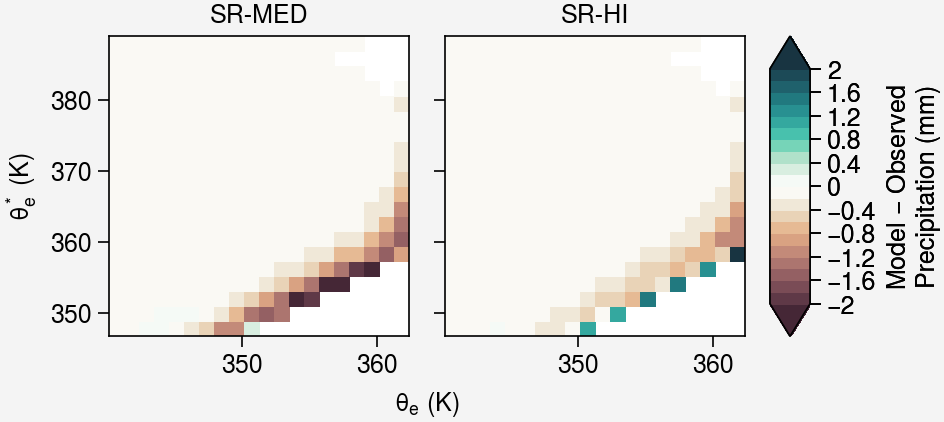

In [11]:
plot_2d('thetae','thetaestar')
plot_2d('thetae','thetaestar',density=False,mode='diff')

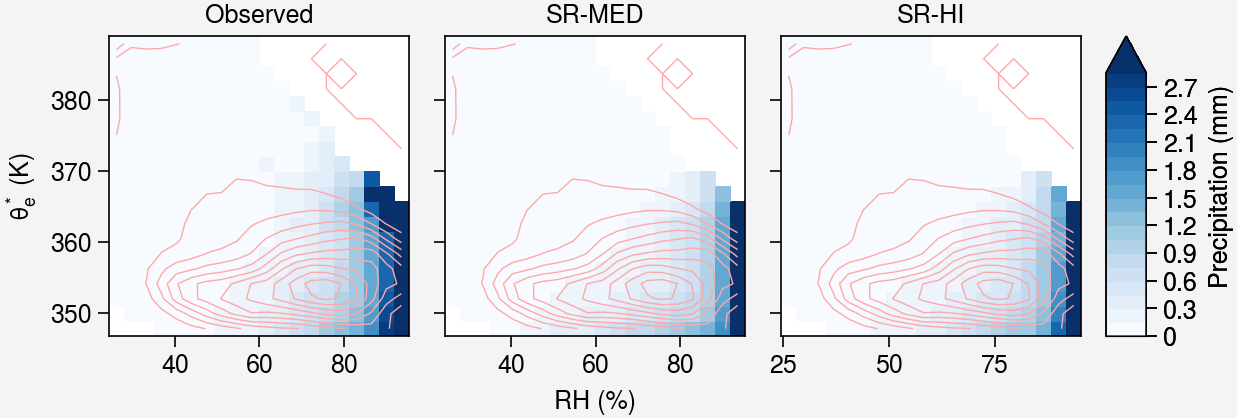

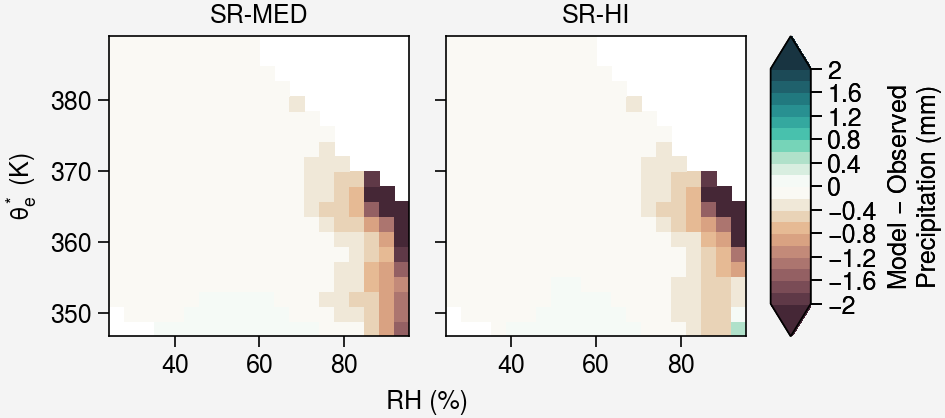

In [12]:
plot_2d('rh','thetaestar')
plot_2d('rh','thetaestar',density=False,mode='diff')

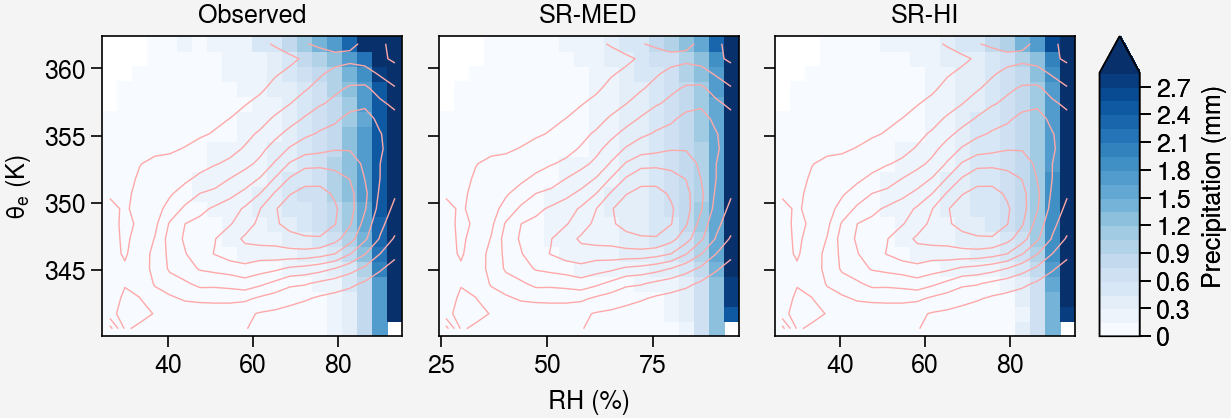

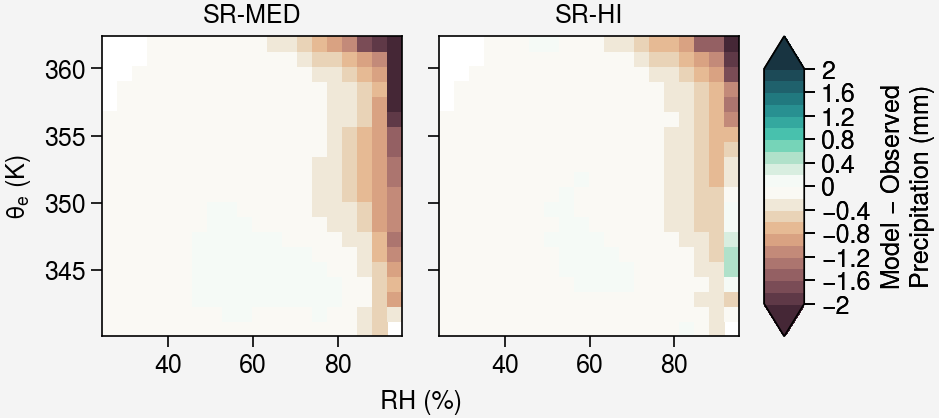

In [13]:
plot_2d('rh','thetae')
plot_2d('rh','thetae',density=False,mode='diff')

In [14]:
def plot_residual_vs(varname,density=True):
    x,xlabel,xunit = physical_predictor(varname)
    models = [name for name in ORDER if name in MODELPRED]
    fig,ax = pplt.subplots(refwidth=1.5)
    if density:
        xc,_,counts = bin_1d(x,obsflat[valid])
        dax = ax.twinx()
        dax.bar(xc,counts,width=xc[1]-xc[0],absolute_width=True,edgecolor='none',color='gray5',alpha=0.3,zorder=0)
        dax.format(ylabel='Sample Count',ylim=(0,4*counts.max()))
    ax.axhline(0,color='gray',linewidth=0.8,linestyle='--')
    for name in models:
        resid = obsflat[valid]-MODELPRED[name][valid]
        xc,residbin,_ = bin_1d(x,resid)
        ax.plot(xc,residbin,color=COLORS[name],linewidth=1.5,label=LABELS[name],zorder=5)
    ax.format(grid=False,xlabel=f'{xlabel} ({xunit})',
              ylabel='Observed $-$ Predicted\nPrecipitation (mm)',title='Residual Structure')
    ax.legend(loc='b',ncols=2)
    pplt.show()

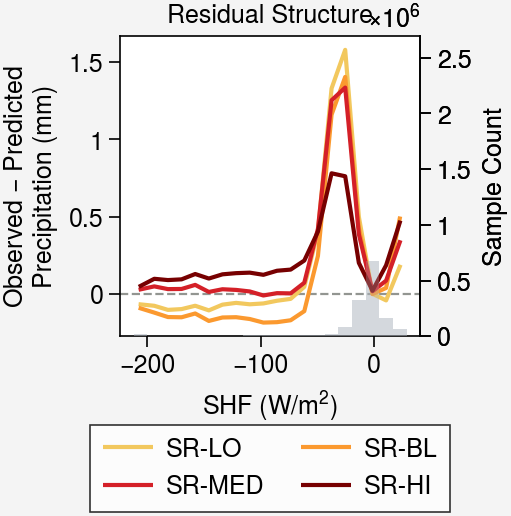

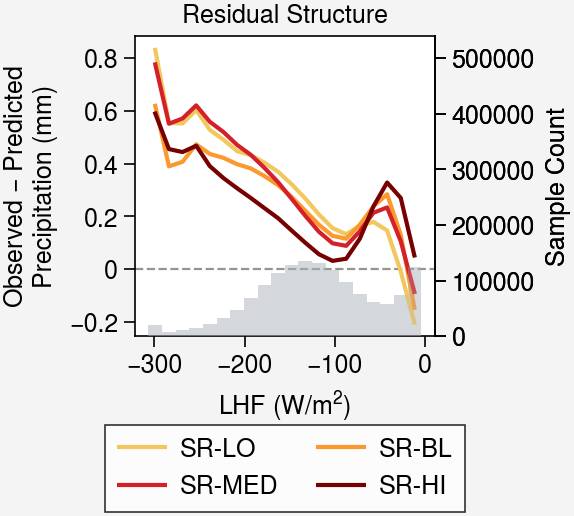

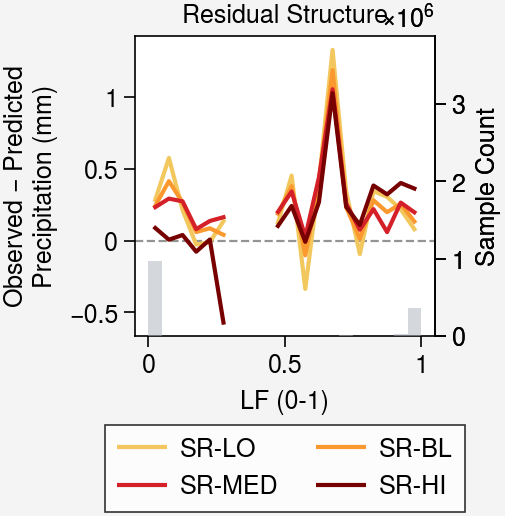

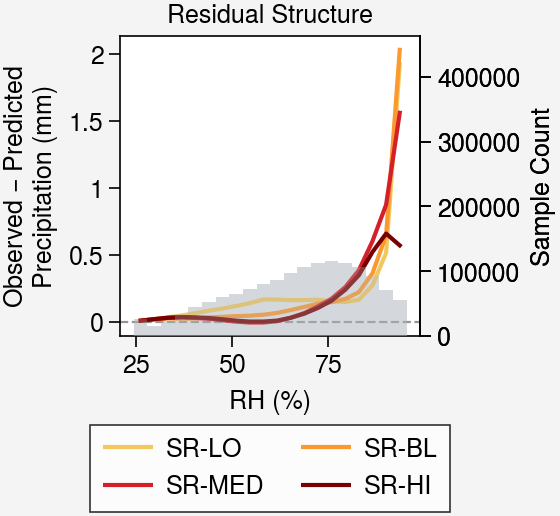

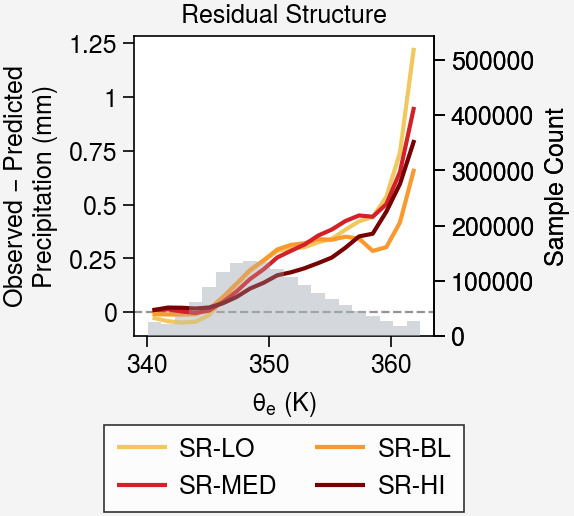

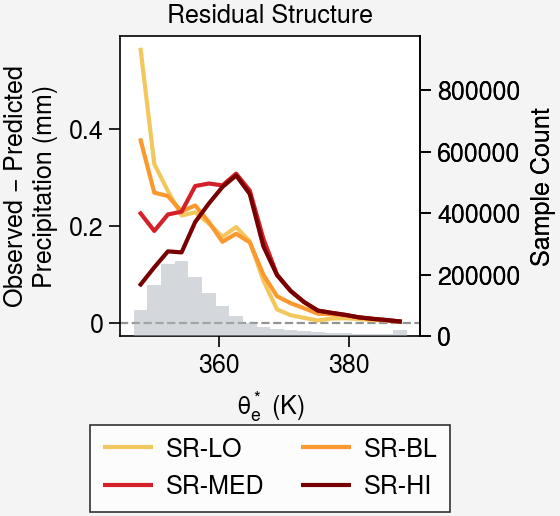

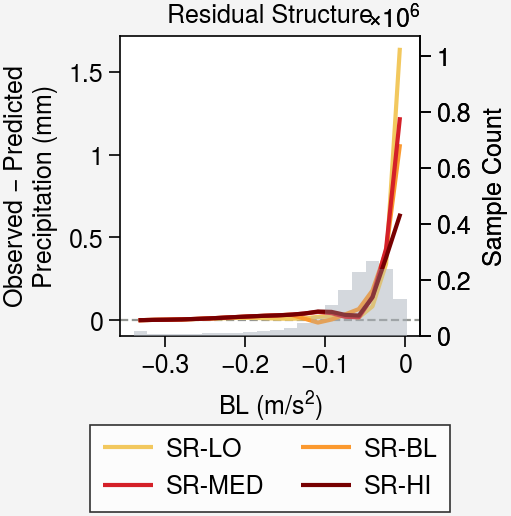

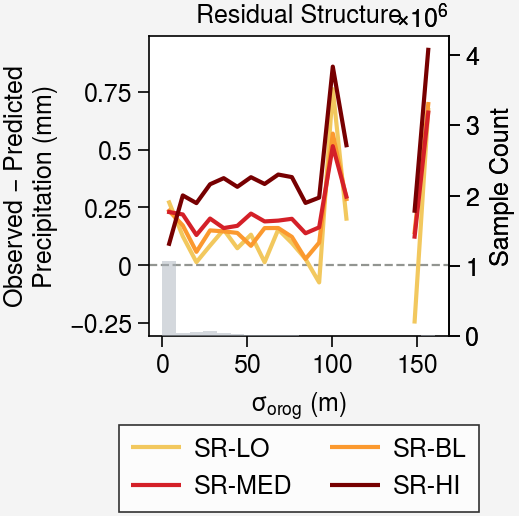

In [15]:
for varname in ['shf','lhf','lf','rh','thetae','thetaestar','bl','sdo']:
    plot_residual_vs(varname)

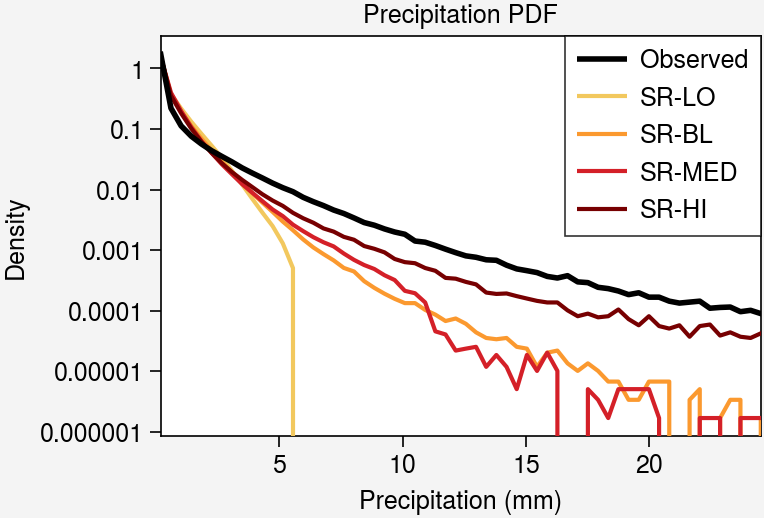

In [16]:
def plot_precip_pdf(nbins=60, phi=99.9):
    obs  = obsflat[valid]
    hi   = np.percentile(obs[obs > 0], phi)
    edges = np.linspace(0, hi, nbins + 1)
    xc    = 0.5 * (edges[:-1] + edges[1:])
    fig, ax = pplt.subplots(refwidth=3, refheight=2)
    obshist, _ = np.histogram(obs, bins=edges, density=True)
    ax.plot(xc, obshist, color='k', linewidth=2, label='Observed', zorder=6)
    for name in ORDER:
        if name not in MODELPRED:
            continue
        predhist, _ = np.histogram(MODELPRED[name][valid], bins=edges, density=True)
        ax.plot(xc, predhist, color=COLORS[name], linewidth=1.5, label=LABELS[name], zorder=5)
    ax.format(grid=False, xlabel='Precipitation (mm)', ylabel='Density',
              title='Precipitation PDF', yscale='log')
    ax.legend(loc='ur', ncols=1)
    pplt.show()

plot_precip_pdf()

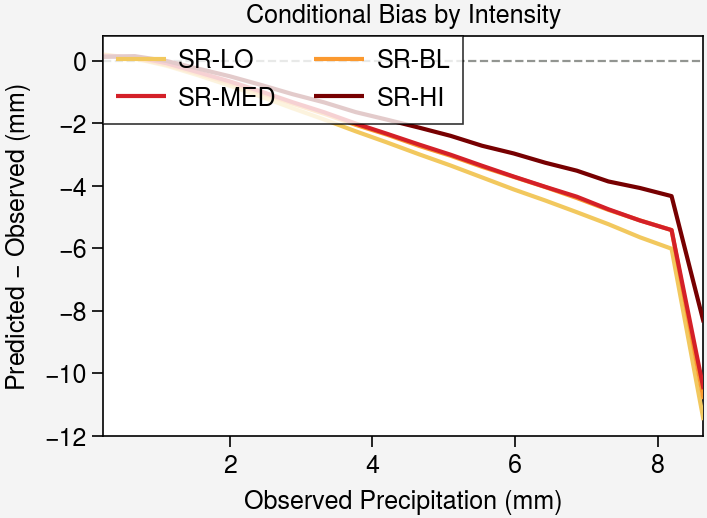

In [17]:
def plot_conditional_bias(nbins=20, minsamples=100):
    obs = obsflat[valid]
    xc, _, _ = bin_1d(obs, obs, nbins=nbins, minsamples=minsamples, plo=0, phi=99)
    fig, ax = pplt.subplots(refwidth=3, refheight=2)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    for name in ORDER:
        if name not in MODELPRED:
            continue
        _, biasbin, _ = bin_1d(obs, MODELPRED[name][valid] - obs,
                               nbins=nbins, minsamples=minsamples, plo=0, phi=99)
        ax.plot(xc, biasbin, color=COLORS[name], linewidth=1.5, label=LABELS[name], zorder=5)
    ax.format(grid=False, xlabel='Observed Precipitation (mm)',
              ylabel='Predicted $-$ Observed (mm)',
              title='Conditional Bias by Intensity')
    ax.legend(loc='ul', ncols=2)
    pplt.show()

plot_conditional_bias()

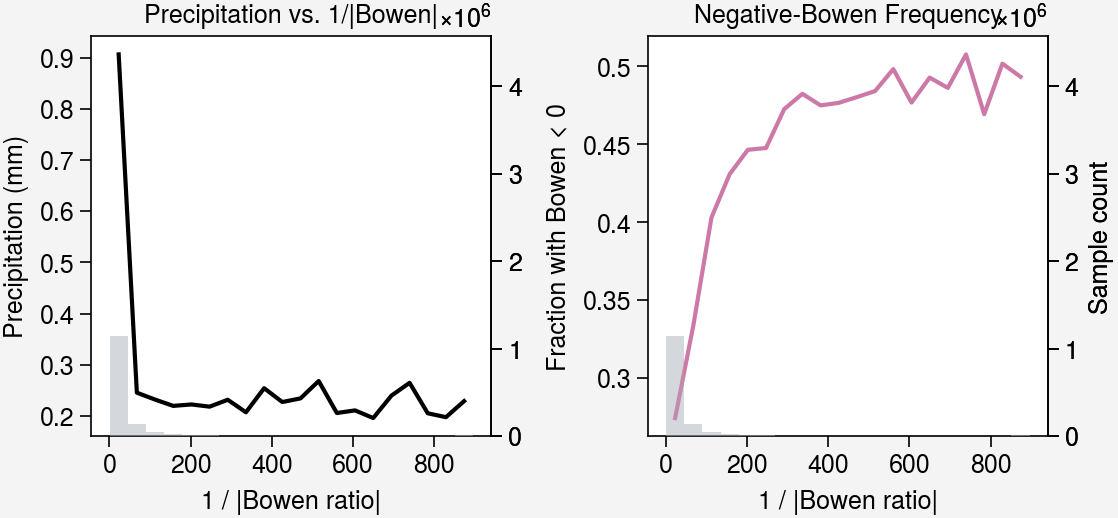

In [18]:
def plot_bowen_analysis(lhfthresh=5.0,density=True):
    lhf      = EXTRAVARS['lhf'][valid]
    bowen    = EXTRAVARS['bow'][valid]
    mask     = np.abs(lhf)>lhfthresh
    invbowen = np.where(mask,1.0/np.abs(bowen),np.nan)
    xc,obsbin,counts = bin_1d(invbowen,obsflat[valid])
    _,fracneg,_      = bin_1d(invbowen,(bowen<0).astype(float))

    fig,axs = pplt.subplots(nrows=1,ncols=2,refwidth=2,share=False)
    if density:
        for j,ax in enumerate(axs):
            dax = ax.twinx()
            dax.bar(xc,counts,width=xc[1]-xc[0],absolute_width=True,edgecolor='none',color='gray5',alpha=0.3,zorder=0)
            dax.format(ylabel='Sample count' if j==len(axs)-1 else '',ylim=(0,4*counts.max()))
    axs[0].plot(xc,obsbin,color='k',linewidth=1.5,zorder=5)
    axs[0].format(grid=False,xlabel='1 / |Bowen ratio|',ylabel='Precipitation (mm)',title='Precipitation vs. 1/|Bowen|')
    axs[1].plot(xc,fracneg,color='C3',linewidth=1.5,zorder=5)
    axs[1].format(grid=False,xlabel='1 / |Bowen ratio|',ylabel='Fraction with Bowen < 0',title='Negative-Bowen Frequency')
    pplt.show()

plot_bowen_analysis()

In [19]:
def compute_thetae_rotation():
    thetae     = VARS['thetae'][valid]*STATS['thetae_std']+STATS['thetae_mean']
    thetaestar = VARS['thetaestar'][valid]*STATS['thetaestar_std']+STATS['thetaestar_mean']
    precip     = obsflat[valid]
    xc,yc,pdp,_ = bin_2d(thetae,thetaestar,precip,nbins=50,minsamples=5)
    Xg,Yg      = np.meshgrid(xc,yc,indexing='ij')
    finite     = np.isfinite(pdp)
    x,y,w      = Xg[finite],Yg[finite],np.clip(pdp[finite],0,None)
    xm,ym      = np.average(x,weights=w),np.average(y,weights=w)
    dx,dy      = x-xm,y-ym
    cov        = np.array([[np.average(dx*dx,weights=w),np.average(dx*dy,weights=w)],
                            [np.average(dx*dy,weights=w),np.average(dy*dy,weights=w)]])
    evals,evecs = np.linalg.eigh(cov)
    w          = evecs[:,np.argmax(evals)]
    thetaerot  = w[0]*thetae+w[1]*thetaestar
    return thetaerot,w

thetaerot,thetaerotweights = compute_thetae_rotation()
print(f'theta_e rotation weights (theta_e, theta_e*): {thetaerotweights}')
print(f'rotation angle from theta_e axis: {np.degrees(np.arctan2(thetaerotweights[1],thetaerotweights[0])):.1f} deg')

EXTRAVARS['thetae_rot']   = np.full(valid.shape,np.nan)
EXTRAVARS['thetae_rot'][valid] = thetaerot
EXTRAUNITS['thetae_rot']  = 'K'
EXTRALABELS['thetae_rot'] = r'$\theta_e$ rotated'

theta_e rotation weights (theta_e, theta_e*): [0.56218044 0.8270146 ]
rotation angle from theta_e axis: 55.8 deg


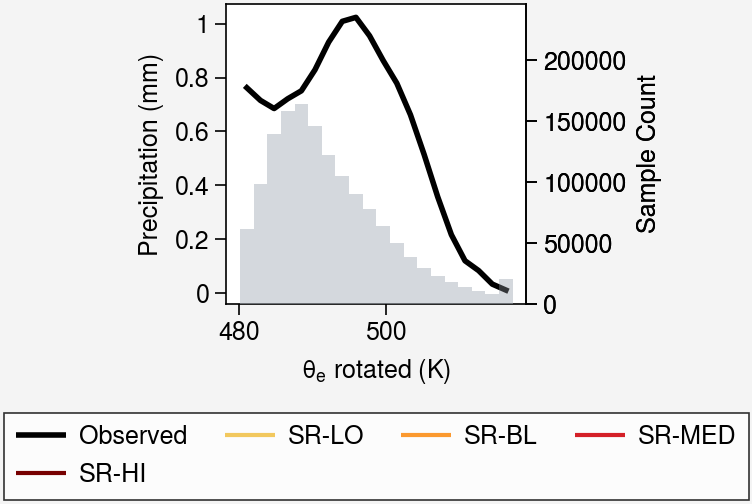

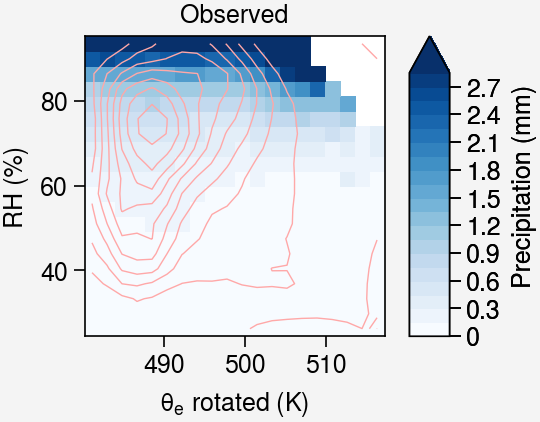

In [20]:
plot_1d(['thetae_rot'])
plot_2d('thetae_rot','rh')